## Working with ChatGPT to make a better version of above

In [2]:
# import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
# from astropy.table import Table
# from astropy.nddata import extract_array
# from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
# from astropy.wcs.utils import skycoord_to_pixel
from reproject import reproject_interp
# from astropy.visualization import make_lupton_rgb
# from astropy.wcs import utils
# import matplotlib.patches as mpatches
# from matplotlib.patches import Rectangle
# from matplotlib.patches import Circle
# from matplotlib.patches import ConnectionPatch

# from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# from astropy.visualization.wcsaxes import WCSAxes
# import astropy.units as u

In [3]:
def orient_north(input_fits_path, output_fits_path, pad_factor):
    # Load FITS
    with fits.open(input_fits_path) as hdu:
        # hdu = hdul[0]
        data = hdu[1].data
        # header = hdu.header
        wcs = WCS(hdu[1].header)
        data[np.isnan(data)] = 0
        data[data<0] = 0.01

        # Get original shape
        ny, nx = data.shape

        # New shape with padding
        pad_nx = int(nx * pad_factor)
        pad_ny = int(ny * pad_factor)

        # Create new WCS header for North-up orientation
        header_north = wcs.deepcopy().to_header()

        # Force PC matrix to identity (North-up)
        header_north['PC1_1'] = 1
        header_north['PC1_2'] = 0
        header_north['PC2_1'] = 0
        header_north['PC2_2'] = 1

        # Adjust reference pixel to be in the center of the new image
        header_north['NAXIS1'] = pad_nx
        header_north['NAXIS2'] = pad_ny
        header_north['CRPIX1'] = pad_nx / 2
        header_north['CRPIX2'] = pad_ny / 2

        wcs_north = WCS(header_north)

        # Reproject
        reprojected_data, _ = reproject_interp((data, wcs), wcs_north, shape_out=(pad_ny, pad_nx))

        # Save output
        fits.writeto(output_fits_path, reprojected_data, wcs_north.to_header(), overwrite=True)
        
    return reprojected_data

In [4]:
path = '/Users/sophiakressy/Desktop/Snazzy_AR_Proposal_figure/2013ai_jhatted/'
miri770 = path + 'jw06553-o001_t001_miri_f770w_jhat.fits'
miri1130 = path + 'jw06553-o001_t001_miri_f1130w_jhat.fits'
miri1500 = path + 'jw06553-o001_t001_miri_f1500w_jhat.fits'

miri_files = [miri770, miri1130, miri1500]
# nir_files = [path+nir1, path+nir2,path+nir3, path+nir4]
mtitles = ['f770w.fits','f1130w.fits','f1500w.fits']
# ntitles = ['f200w','f300m','f335m',"f360m"]

for i in range(len(miri_files)):
    orient_north(miri_files[i], path+'North_'+mtitles[i], pad_factor=2.0)
# for nfile in range(len(nir_files)):
#     orient_north(nir_files[nfile],npath+'North_'+ntitles[nfile],pad_factor=2.0)

Set OBSGEO-B to    12.402905 from OBSGEO-[XYZ].
Set OBSGEO-H to 1644367145.251 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    12.402905 from OBSGEO-[XYZ].
Set OBSGEO-H to 1644367145.251 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    12.402905 from OBSGEO-[XYZ].
Set OBSGEO-H to 1644367145.251 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    12.402905 from OBSGEO-[XYZ].
Set OBSGEO-H to 1644367145.251 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_interp
from astropy.visualization import AsinhStretch

# Paths
path = '/Users/sophiakressy/Desktop/Snazzy_AR_Proposal_figure/2013ai_jhatted/'
miri770 = path + 'North_f770w.fits'
miri1130 = path + 'North_f1130w.fits'
miri1500 = path + 'North_f1500w.fits'

# Open data
with fits.open(miri770) as hdu1, fits.open(miri1130) as hdu2, fits.open(miri1500) as hdu3:
    data_770 = hdu1[0].data
    data_1130 = hdu2[0].data
    data_1500 = hdu3[0].data
    wcs_ref = WCS(hdu1[0].header)

# Handle NaNs and negatives
for arr in [data_770, data_1130, data_1500]:
    arr[np.isnan(arr)] = 0
    arr[arr < 0] = 0

# Reproject to reference WCS (F770W)
data_1130_reproj, _ = reproject_interp((data_1130, WCS(hdu2[0].header)), wcs_ref)
data_1500_reproj, _ = reproject_interp((data_1500, WCS(hdu3[0].header)), wcs_ref)

# Crop region
x, y, window = int(2120.8082), int(2131.7217), 100
crop = (slice(y - window, y + window), slice(x - window, x + window))
f770 = data_770[crop]
f1130 = data_1130_reproj[crop]
f1500 = data_1500_reproj[crop]

# Normalize each to similar scale
def norm(arr):
    return arr / np.nanpercentile(arr, 99.5)

f770_n = norm(f770)
f1130_n = norm(f1130)
f1500_n = norm(f1500)


Set OBSGEO-B to    12.402905 from OBSGEO-[XYZ].
Set OBSGEO-H to 1644367145.251 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


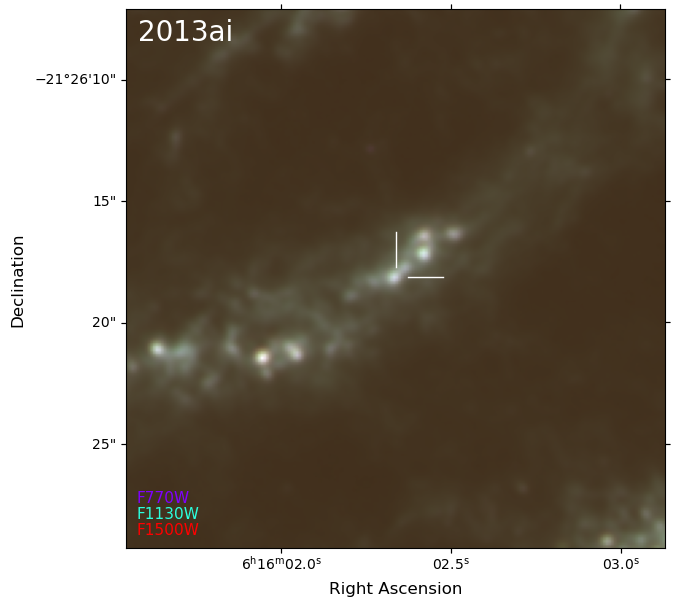

In [17]:
# --- RGB weights ---
weights = {
    'F770W':  (0.50, 0.00, 1.00),
    'F1130W': (0.17, 1.00, 0.87),
    'F1500W': (1.00, 0.0, 0.00),
}

# Combine into RGB channels
R = (weights['F770W'][0] * f770_n +
     weights['F1130W'][0] * f1130_n +
     weights['F1500W'][0] * f1500_n)
G = (weights['F770W'][1] * f770_n +
     weights['F1130W'][1] * f1130_n +
     weights['F1500W'][1] * f1500_n)
B = (weights['F770W'][2] * f770_n +
     weights['F1130W'][2] * f1130_n +
     weights['F1500W'][2] * f1500_n)

# Apply stretch
stretch = AsinhStretch(2)
R = stretch(R / np.nanmax(R))
G = stretch(G / np.nanmax(G))
B = stretch(B / np.nanmax(B))

# Stack RGB
rgb = np.dstack([R, G, B])
rgb = np.clip(rgb, 0, 1)

# --- Plot ---
fig = plt.figure(figsize=(7,7))
ax = plt.subplot(projection=wcs_ref)
ax.imshow(np.fliplr(rgb), origin='lower')
ax.set_xlabel('Right Ascension', fontsize=12)
ax.set_ylabel('Declination', fontsize=12)

# --- Add stacked bottom-left labels ---
labels = ['F1500W','F1130W', 'F770W']  # reversed order (blue → red)
y_start = 0.02      # bottom offset
y_step = 0.03       # vertical spacing between labels

for i, filt in enumerate(labels):
    color = weights[filt]
    ax.text(
        0.02, y_start + i * y_step, filt,
        color=color,
        transform=ax.transAxes,
        fontsize=11,
        ha='left', va='bottom',
    )
#fontweight='bold'

hx_line = [(window)+4, (window)+17]
hy_line = [(window), (window)]

vx_line = [(window-0.5), (window-0.5)]
vy_line = [(window)+4, (window)+17]

ax.plot(hx_line, hy_line, color='white', linewidth=1, linestyle='-')
ax.plot(vx_line, vy_line, color='white', linewidth=1, linestyle='-')

ax.text(4, window*2-12, '2013ai', fontsize=20, color = 'white')

# plt.show()
plt.savefig('/Users/sophiakressy/Desktop/Snazzy_AR_Proposal_figure/2013ai.pdf')
